# Punishment Study 2.1.2 — NLP Pipeline
## Notebook 3 (v2): Embeddings, Prototype Similarity, & Method Evolution

**Author:** David G. Kamper  
**Project:** *The Dark Side of Punishment*  
**Pipeline stage:** 3 of 4

---

### What this notebook does

This notebook generates semantic embeddings for the 496 sentencing justifications and prototype sentence sets, then computes prototype similarity scores. It also tells a **method-evolution story**: we run three generations of embedding models (2021, 2024, 2026) on the same data and the same prototypes, so the manuscript can transparently show how the apparent dark-closer percentage depends on the embedding model used.

### The three embedding models

| Model | Year | Dim | Architecture | Why we run it |
|---|---|---|---|---|
| `all-mpnet-base-v2` | 2021 | 768 | MPNet (compact transformer) | The v2 pipeline's model; reproduces the 67.5% finding |
| `BAAI/bge-large-en-v1.5` | 2024 | 1024 | BERT-large with retrieval-tuning | Open-source, top of HF leaderboard |
| `voyage-4-large` | 2026 | 2048 | Mixture-of-Experts | Commercial flagship, MoE architecture |

Three independent embedding models running the same prototype-similarity logic on the same data. If they disagree (and they do), that's the methodological story.

### The five prototype sets

| Set | Register | Lexical overlap with scale items | Purpose |
|---|---|---|---|
| Original (A) | Casual lay | High | v2 baseline |
| Formal (B1) | Academic | Low | Tests register sensitivity |
| Colloquial (B2) | Casual lay | High | Tests casual phrasing |
| **LayFormal (NEW)** | **Casual lay** | Low | **Formal concepts in lay register** |
| AntiTaut (B4) | Mixed | Minimized | Tests construct-overlap critique |

**Why LayFormal matters:** the Formal set keeps proper academic distinctions (incapacitation ≠ deterrence ≠ retribution) but writes them in academic vocabulary, which doesn't match how participants actually wrote. LayFormal preserves the conceptual rigor of the Formal set but uses everyday language matching the participant register, eliminating the register-mismatch confound.

### B3 sensitivity (inline, not deferred to Notebook 4)

For each (model × set), we additionally compute:
- **B3a:** Standard 4-prosocial vs 3-dark grouping (the headline number)
- **B3b:** Retribution removed (3-prosocial vs 3-dark)
- **B3c:** Retribution as dark (3-prosocial vs 4-dark)

Final master table: **3 models × 5 sets × 3 B3 variants = 45 cells.**

### Why we now run three models

When we ran BGE and voyage-4 on the Original prototypes, the % closer-to-dark dropped from v2's 67.5% (mpnet) to ~21–28%. We need to verify this is genuinely about model architecture differences, not subtle code-path differences between v2 and v3 pipelines. Running mpnet *inside this notebook* on the *same code path as BGE/voyage* is the apples-to-apples test.

**Hypothesis:** mpnet will reproduce ~67% closer-to-dark on the Original set. BGE and voyage will land much lower. The convergence between BGE and voyage (and divergence from mpnet) tells us the v2 finding was a property of the older embedding model, not the data.

### Output

- `03_embedding_features.csv` — main features file
- `mpnet_response_embeddings.npy`, `bge_response_embeddings.npy`, `voyage_response_embeddings.npy` — cached for Notebook 4
- `prototype_sensitivity_master.csv` — 45-cell master table
- `embedding_convergence.csv` — pairwise model agreement
- Several PNG visualizations

### Setup

**Runtime → Change runtime type → T4 GPU**. Reads `VOYAGE_API_KEY` from Colab Secrets.

### Cost & runtime

- mpnet on T4: ~10 sec
- BGE on T4: ~30 sec  
- voyage-4-large API: ~30 sec, < $0.05
- Total: ~5 minutes


---

## Section 0: Setup


In [32]:
# === INSTALL ===
!pip install -q sentence-transformers==3.0.1 voyageai
print('✓ Packages installed')


✓ Packages installed


In [33]:
# === IMPORTS ===
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

import torch
from sentence_transformers import SentenceTransformer
from scipy.stats import pearsonr

import voyageai
from google.colab import files, userdata

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
np.set_printoptions(precision=4, suppress=True)

if torch.cuda.is_available():
    print(f'✓ GPU available: {torch.cuda.get_device_name(0)}')
else:
    print('⚠ No GPU — embedding models will be slow but still run')

print('✓ Imports complete')


✓ GPU available: Tesla T4
✓ Imports complete


In [34]:
# === API KEY FROM COLAB SECRETS ===
try:
    Punishment_VoyageAPI = userdata.get('Punishment_VoyageAPI')
    if not Punishment_VoyageAPI:
        raise ValueError('Empty key')
    print(f'✓ Voyage API key loaded (ends in ...{Punishment_VoyageAPI[-4:]})')
except Exception as e:
    print(f'⚠ Could not load Punishment_VoyageAPI: {e}')
    raise

voyage_client = voyageai.Client(api_key=Punishment_VoyageAPI)
VOYAGE_MODEL = 'voyage-4-large'
print(f'✓ Voyage client ready (model = {VOYAGE_MODEL})')


✓ Voyage API key loaded (ends in ...weWc)
✓ Voyage client ready (model = voyage-4-large)


---

## Section 1: Load `02_classification_features.csv`


In [35]:
# === LOAD INPUT ===
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f'✓ Loaded: {filename}')
print(f'  Rows: {len(df)}, Columns: {len(df.columns)}')

assert 'text_combined' in df.columns, 'Run Notebook 1 first'
assert 'claude_ml_prosocial_minus_dark' in df.columns, 'Run Notebook 2 first'


Saving 02_classification_features.csv to 02_classification_features (1).csv
✓ Loaded: 02_classification_features (1).csv
  Rows: 496, Columns: 242


---

## Section 2: Five prototype sentence sets

Five variants × seven categories × three sentences = 105 prototypes total.

| Set | Register | Lexical overlap | Notes |
|---|---|---|---|
| Original | Lay | High | v2 baseline; uses 'suffer', 'payback', 'rot' |
| Formal | Academic | Low | Uses formal terms like 'incarceration', 'retaliatory' |
| Colloquial | Lay | High | Casual emotional phrasing |
| **LayFormal** | **Lay** | **Low** | Formal concepts in everyday language |
| AntiTaut | Mixed | Minimized | Eliminates surface lexical overlap with scale items |

**LayFormal example (suffering):** *"He should have a hard time in prison and not enjoy it."*  
Compare to:
- Original: *"I want him to suffer in prison."* (uses scale word 'suffer')
- Formal: *"Incarceration should involve genuine hardship and deprivation."* (academic register)
- Colloquial: *"I hope every day in there is awful for him."* (lay register but emotional)

LayFormal sits in the lay register like Original/Colloquial but avoids scale-keyword vocabulary like Formal/AntiTaut.


In [36]:
# === PROTOTYPE SETS ===
PROTO_ORIGINAL = {
    'deterrence': [
        'This sentence will deter others from committing similar crimes.',
        'Punishment sends a message that crime does not pay.',
        'This will make others think twice before breaking the law.',
    ],
    'incapacitation': [
        'This keeps dangerous criminals away from society.',
        'The public needs to be protected from this offender.',
        'Society is safer with this person behind bars.',
    ],
    'rehabilitation': [
        'Time in prison gives the offender a chance to reform.',
        'With proper programs, this person can become a productive member of society.',
        'Everyone deserves a second chance to become a better person.',
    ],
    'retribution': [
        'This sentence is proportional to the severity of the crime.',
        'Justice requires that wrongdoers face appropriate consequences.',
        'The offender deserves this punishment for their actions.',
    ],
    'revenge': [
        'He deserves to suffer for what he did.',
        'This is payback for the harm he caused.',
        'An eye for an eye - he should feel the same pain.',
    ],
    'suffering': [
        'I want him to suffer in prison.',
        'Prison should be painful and miserable.',
        'Let him rot and suffer behind bars.',
    ],
    'exclusion': [
        'He has no place in our society.',
        'Lock him up and throw away the key.',
        'He forfeited his right to be part of society.',
    ],
}


In [37]:
PROTO_FORMAL = {
    'deterrence': [
        'The purpose of this sentence is to prevent future criminal behavior.',
        'A strong sentence serves as a warning to potential offenders.',
        'This punishment will reduce crime by making the costs of offending clear.',
    ],
    'incapacitation': [
        'Incarceration removes this individual from society to prevent further harm.',
        'While incarcerated, the offender cannot victimize additional people.',
        'This sentence serves the public interest by confining a dangerous individual.',
    ],
    'rehabilitation': [
        'The correctional system should provide opportunities for personal transformation.',
        'Access to education and counseling during incarceration can reduce recidivism.',
        'The goal is for this individual to eventually reintegrate as a contributing member of society.',
    ],
    'retribution': [
        'The severity of this sentence reflects the gravity of the offense.',
        'Proportional punishment is a fundamental requirement of justice.',
        'The offender has earned this consequence through their criminal actions.',
    ],
    'revenge': [
        'The offender should experience the same kind of suffering they caused.',
        'What goes around comes around. They deserve to pay dearly.',
        'There should be retaliatory consequences that match the harm done.',
    ],
    'suffering': [
        'Incarceration should involve genuine hardship and deprivation.',
        'The conditions of confinement should cause the offender real distress.',
        'A comfortable prison sentence would be an insufficient consequence.',
    ],
    'exclusion': [
        'This individual has permanently forfeited their right to participate in society.',
        'Some offenders can never be trusted to live among law-abiding citizens.',
        'Permanent removal from the community is the only acceptable outcome.',
    ],
}


In [38]:
PROTO_COLLOQUIAL = {
    'deterrence': [
        'Maybe seeing what happened to him will stop someone else from doing the same thing.',
        'If people know they will go to jail for a long time, they will not commit crimes.',
        'This sends a message: if you do this, this is what happens to you.',
    ],
    'incapacitation': [
        'He is dangerous and people are not safe with him on the streets.',
        'As long as he is in prison, he cannot hurt anyone else.',
        'We need him away from regular people so no one else gets hurt.',
    ],
    'rehabilitation': [
        'Maybe with enough time and help he can change and be a good person.',
        'I think he can learn from this and not make the same mistakes again.',
        'He needs counseling and support to deal with whatever led him here.',
    ],
    'retribution': [
        'He did something terrible and he needs to face the consequences for it.',
        'The sentence should be fair based on what he actually did.',
        'He is responsible for his choices and this is the price he has to pay.',
    ],
    'revenge': [
        'He should get what is coming to him after what he did.',
        "He ruined someone's life so his life should be ruined too.",
        "He took something away and now it's his turn to lose something.",
    ],
    'suffering': [
        'I hope every day in there is awful for him.',
        'Prison should not be easy, it should be horrible for someone like him.',
        'He should have to feel something terrible every single day.',
    ],
    'exclusion': [
        'People like him should not be walking around with the rest of us.',
        'He gave up his right to be in society when he did what he did.',
        'Get him out and keep him out, we do not want him here.',
    ],
}


In [39]:
# === PROTOTYPE SET: LAYFORMAL (NEW) ===
# Goal: Preserve formal academic CONCEPTS (e.g., incapacitation ≠ deterrence) while writing
# in plain English at participant reading level. This is the cleanest comparison set —
# matches participant register without surrendering conceptual rigor.

PROTO_LAYFORMAL = {
    'deterrence': [
        'A long sentence will make other people think twice before doing this kind of thing.',
        'When people see what happens, they will be less likely to do it themselves.',
        'A serious punishment shows others what they are risking if they break the law.',
    ],
    'incapacitation': [
        'Locking him up means he cannot go out and hurt anyone else while he is in prison.',
        'As long as he is in there, the rest of us are safe from him.',
        'Keeping him off the streets is what stops him from doing this again right now.',
    ],
    'rehabilitation': [
        'Time inside should help him work on himself and come out better than he went in.',
        'With the right kind of help, he could change and not end up back in prison.',
        'The point should be that he learns something and becomes someone different.',
    ],
    'retribution': [
        'The punishment should match what he actually did, not be way more or way less.',
        'Whatever he gets needs to fit the crime he committed.',
        'He should answer for what he did at a level that is fair to the seriousness of it.',
    ],
    'revenge': [
        'He should feel something close to what he made the victim feel.',
        'Whatever he did to that person should come back at him in some way.',
        'The harm he caused should be returned to him so he understands.',
    ],
    'suffering': [
        'He should have a hard time in prison and not enjoy it.',
        'Time inside should be genuinely tough on him, not easy or comfortable.',
        'His life behind bars should be miserable enough to really matter.',
    ],
    'exclusion': [
        'He should be cut off from the rest of us for good.',
        'Someone who does this no longer belongs around regular people.',
        'He should be kept away from society permanently with no way back in.',
    ],
}


In [40]:
PROTO_ANTITAUT = {
    'deterrence': [
        'Other potential offenders may be dissuaded by witnessing this outcome.',
        'A serious consequence here will discourage similar conduct elsewhere.',
        'The example set will reduce the likelihood of repeat behavior in the population.',
    ],
    'incapacitation': [
        'Confinement physically prevents this individual from committing additional offenses.',
        'While detained, the offender is unable to cause further harm to community members.',
        'Removing this person from circulation eliminates the immediate ongoing risk.',
    ],
    'rehabilitation': [
        'The custodial period offers opportunity for psychological growth and skill development.',
        'Therapeutic intervention during this time can address underlying behavioral patterns.',
        'With appropriate resources, this individual could resume productive community membership.',
    ],
    'retribution': [
        'The magnitude of the response should correspond to the gravity of the wrongdoing.',
        'Equitable consequences require alignment between the offense and its outcome.',
        'Moral accountability demands that wrongful acts carry commensurate responses.',
    ],
    'revenge': [
        'The wrongdoer ought to experience equivalent loss to what was inflicted on the victim.',
        'The harm caused must be returned to the person who caused it.',
        'There is something owed to the victim that can only be settled by reciprocal injury.',
    ],
    'suffering': [
        'The conditions of confinement should be genuinely unpleasant for the inmate.',
        'Daily existence behind those walls ought to be one of difficulty and grimness.',
        'The custodial environment should impose real psychological and physical hardship.',
    ],
    'exclusion': [
        'This person should be permanently severed from participation in shared social life.',
        'Some individuals have abandoned the standing required to live alongside others.',
        'A complete and lasting separation from the community is the only fitting response.',
    ],
}

PROTOTYPE_SETS = {
    'Original':   PROTO_ORIGINAL,
    'Formal':     PROTO_FORMAL,
    'Colloquial': PROTO_COLLOQUIAL,
    'LayFormal':  PROTO_LAYFORMAL,
    'AntiTaut':   PROTO_ANTITAUT,
}

PROSOCIAL_CATS = ['deterrence', 'incapacitation', 'rehabilitation', 'retribution']
DARK_CATS      = ['revenge', 'suffering', 'exclusion']
ALL_CATS       = PROSOCIAL_CATS + DARK_CATS

n_total = sum(len(v) for s in PROTOTYPE_SETS.values() for v in s.values())
print(f'✓ {len(PROTOTYPE_SETS)} prototype sets × 7 categories × 3 sentences = {n_total} total prototypes')


✓ 5 prototype sets × 7 categories × 3 sentences = 105 total prototypes


---

## Section 3: Embedding helpers (apply to all 3 models identically)

Define a single function that takes any embedding model + any prototype set and produces:
- Per-category similarity columns
- Standard B3a aggregates (4 prosocial vs 3 dark)
- B3b aggregates (3 prosocial — retribution removed — vs 3 dark)
- B3c aggregates (3 prosocial vs 4 dark — retribution moved to dark)

By using the same function for all three models, we guarantee apples-to-apples comparison.


In [41]:
# === SHARED HELPERS ===
def normalize_rows(emb_matrix):
    """L2-normalize each row so cosine == dot product."""
    norms = np.linalg.norm(emb_matrix, axis=1, keepdims=True)
    return emb_matrix / np.clip(norms, 1e-8, None)

def normalize_vec(v):
    n = np.linalg.norm(v)
    return v / max(n, 1e-8)

def compute_proto_centroids(proto_set, embed_fn):
    """For each category, embed all sentences, average, renormalize.
    embed_fn(list_of_strings) -> np.array (n, dim) already row-normalized."""
    centroids = {}
    for cat, sentences in proto_set.items():
        emb = embed_fn(sentences)
        centroid = normalize_vec(emb.mean(axis=0))
        centroids[cat] = centroid
    return centroids

def add_similarity_columns(df_target, response_emb, proto_centroids, model_name, set_name):
    """Compute and add similarity columns for one (model × set) combination.

    Adds columns:
      {model_name}_{set_prefix}_{cat}            for each of 7 categories
      {model_name}_{set_prefix}_b3a_pro_minus_dark    standard 4-vs-3
      {model_name}_{set_prefix}_b3b_pro_minus_dark    retribution removed (3-vs-3)
      {model_name}_{set_prefix}_b3c_pro_minus_dark    retribution as dark (3-vs-4)
    """
    set_prefix = set_name.lower() if set_name != 'Original' else 'orig'
    # Per-category sims
    for cat, centroid in proto_centroids.items():
        df_target[f'{model_name}_{set_prefix}_{cat}'] = response_emb @ centroid
    # B3a: standard 4 prosocial vs 3 dark
    pro_a = [f'{model_name}_{set_prefix}_{c}' for c in PROSOCIAL_CATS]
    dark_a = [f'{model_name}_{set_prefix}_{c}' for c in DARK_CATS]
    df_target[f'{model_name}_{set_prefix}_b3a_pro_minus_dark'] = (
        df_target[pro_a].mean(axis=1) - df_target[dark_a].mean(axis=1))
    # B3b: retribution removed
    pro_b = [f'{model_name}_{set_prefix}_{c}' for c in PROSOCIAL_CATS if c != 'retribution']
    df_target[f'{model_name}_{set_prefix}_b3b_pro_minus_dark'] = (
        df_target[pro_b].mean(axis=1) - df_target[dark_a].mean(axis=1))
    # B3c: retribution as dark
    dark_c = dark_a + [f'{model_name}_{set_prefix}_retribution']
    df_target[f'{model_name}_{set_prefix}_b3c_pro_minus_dark'] = (
        df_target[pro_b].mean(axis=1) - df_target[dark_c].mean(axis=1))
    return df_target

print('✓ Helpers defined')


✓ Helpers defined


---

## Section 4: `all-mpnet-base-v2` (2021) — the v2 baseline

First we run the same model the v2 pipeline used. This reproduces (or fails to reproduce) the 67.5% closer-to-dark finding *inside this notebook's code path*. If mpnet's number here matches v2's prior result, we know the v3 vs v2 difference is genuinely about embedding model capability, not subtle code-path differences.


In [42]:
# === LOAD MPNET ===
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Loading all-mpnet-base-v2 (~440 MB)...')
mpnet = SentenceTransformer('sentence-transformers/all-mpnet-base-v2', device=device)
print(f'✓ mpnet loaded (device={device}, dim={mpnet.get_sentence_embedding_dimension()})')


Loading all-mpnet-base-v2 (~440 MB)...
✓ mpnet loaded (device=cuda, dim=768)


In [43]:
# === MPNET RESPONSE EMBEDDINGS ===
texts = df['text_combined'].fillna('').tolist()
t0 = time.time()
mpnet_response_emb = mpnet.encode(
    texts, batch_size=32, show_progress_bar=True,
    convert_to_numpy=True, normalize_embeddings=True,
)
print(f'✓ mpnet responses: {mpnet_response_emb.shape} in {time.time()-t0:.1f} sec')
np.save('mpnet_response_embeddings.npy', mpnet_response_emb)


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

✓ mpnet responses: (496, 768) in 2.6 sec


In [44]:
# === MPNET PROTOTYPES + SIMILARITY (all 5 sets) ===
def embed_mpnet(sentences):
    return mpnet.encode(sentences, normalize_embeddings=True, convert_to_numpy=True)

for set_name, proto_set in PROTOTYPE_SETS.items():
    centroids = compute_proto_centroids(proto_set, embed_mpnet)
    df = add_similarity_columns(df, mpnet_response_emb, centroids, 'mpnet', set_name)
    set_prefix = set_name.lower() if set_name != 'Original' else 'orig'
    pct = (df[f'mpnet_{set_prefix}_b3a_pro_minus_dark'] < 0).mean() * 100
    diff = df[f'mpnet_{set_prefix}_b3a_pro_minus_dark'].mean()
    print(f'  mpnet × {set_name:11s}: {pct:5.1f}% closer to dark  |  mean diff = {diff:+.4f}')


  mpnet × Original   :  67.5% closer to dark  |  mean diff = -0.0320
  mpnet × Formal     :  73.0% closer to dark  |  mean diff = -0.0220
  mpnet × Colloquial :  32.5% closer to dark  |  mean diff = +0.0138
  mpnet × LayFormal  :  57.3% closer to dark  |  mean diff = -0.0101
  mpnet × AntiTaut   :  30.6% closer to dark  |  mean diff = +0.0203


---

## Section 5: `BAAI/bge-large-en-v1.5` (2024)

Second-generation embedding: BERT-large with retrieval-tuning. Open-source, top of the HuggingFace zero-shot retrieval leaderboard.


In [45]:
# === LOAD BGE ===
print('Loading BGE-large-en-v1.5 (~1.3 GB)...')
bge = SentenceTransformer('BAAI/bge-large-en-v1.5', device=device)
print(f'✓ BGE loaded (dim={bge.get_sentence_embedding_dimension()})')

t0 = time.time()
bge_response_emb = bge.encode(
    texts, batch_size=32, show_progress_bar=True,
    convert_to_numpy=True, normalize_embeddings=True,
)
print(f'✓ BGE responses: {bge_response_emb.shape} in {time.time()-t0:.1f} sec')
np.save('bge_response_embeddings.npy', bge_response_emb)


Loading BGE-large-en-v1.5 (~1.3 GB)...
✓ BGE loaded (dim=1024)


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

✓ BGE responses: (496, 1024) in 7.7 sec


In [46]:
# === BGE PROTOTYPES + SIMILARITY (all 5 sets) ===
def embed_bge(sentences):
    return bge.encode(sentences, normalize_embeddings=True, convert_to_numpy=True)

for set_name, proto_set in PROTOTYPE_SETS.items():
    centroids = compute_proto_centroids(proto_set, embed_bge)
    df = add_similarity_columns(df, bge_response_emb, centroids, 'bge', set_name)
    set_prefix = set_name.lower() if set_name != 'Original' else 'orig'
    pct = (df[f'bge_{set_prefix}_b3a_pro_minus_dark'] < 0).mean() * 100
    diff = df[f'bge_{set_prefix}_b3a_pro_minus_dark'].mean()
    print(f'  bge × {set_name:11s}: {pct:5.1f}% closer to dark  |  mean diff = {diff:+.4f}')


  bge × Original   :  21.0% closer to dark  |  mean diff = +0.0294
  bge × Formal     :  34.3% closer to dark  |  mean diff = +0.0100
  bge × Colloquial :  22.8% closer to dark  |  mean diff = +0.0165
  bge × LayFormal  :  70.6% closer to dark  |  mean diff = -0.0134
  bge × AntiTaut   :  50.6% closer to dark  |  mean diff = -0.0014


---

## Section 6: `voyage-4-large` (2026)

Third-generation: MoE flagship from Voyage AI, released January 2026. 2048-dim embeddings via API. Symmetric mode (`input_type=None`) since responses and prototypes are peer texts, not query/document pairs.


In [47]:
# === VOYAGE EMBEDDING (BATCHED + RETRIES) ===
def voyage_embed_batch(text_list, batch_size=64):
    out = []
    for i in range(0, len(text_list), batch_size):
        batch = [t if isinstance(t, str) and t.strip() else ' ' for t in text_list[i:i+batch_size]]
        for attempt in range(3):
            try:
                result = voyage_client.embed(batch, model=VOYAGE_MODEL, input_type=None)
                out.extend(result.embeddings)
                break
            except Exception as e:
                if attempt == 2: raise
                wait = 2 ** attempt
                print(f'  Retry {attempt+1} after {wait}s: {e}')
                time.sleep(wait)
    return normalize_rows(np.array(out))

t0 = time.time()
voyage_response_emb = voyage_embed_batch(texts, batch_size=64)
print(f'✓ Voyage responses: {voyage_response_emb.shape} in {time.time()-t0:.1f} sec')
np.save('voyage_response_embeddings.npy', voyage_response_emb)


✓ Voyage responses: (496, 1024) in 2.1 sec


In [48]:
# === VOYAGE PROTOTYPES + SIMILARITY (all 5 sets) ===
def embed_voyage(sentences):
    return voyage_embed_batch(sentences, batch_size=32)

for set_name, proto_set in PROTOTYPE_SETS.items():
    centroids = compute_proto_centroids(proto_set, embed_voyage)
    df = add_similarity_columns(df, voyage_response_emb, centroids, 'voyage', set_name)
    set_prefix = set_name.lower() if set_name != 'Original' else 'orig'
    pct = (df[f'voyage_{set_prefix}_b3a_pro_minus_dark'] < 0).mean() * 100
    diff = df[f'voyage_{set_prefix}_b3a_pro_minus_dark'].mean()
    print(f'  voyage × {set_name:11s}: {pct:5.1f}% closer to dark  |  mean diff = {diff:+.4f}')


  voyage × Original   :  28.4% closer to dark  |  mean diff = +0.0285
  voyage × Formal     :   3.0% closer to dark  |  mean diff = +0.0782
  voyage × Colloquial :  22.8% closer to dark  |  mean diff = +0.0241
  voyage × LayFormal  :  33.3% closer to dark  |  mean diff = +0.0124
  voyage × AntiTaut   :  15.5% closer to dark  |  mean diff = +0.0342


---

## Section 7: Master sensitivity table (3 × 5 × 3 = 45 cells)

The headline manuscript output. For each (embedding model × prototype set × B3 variant), we report:
- % closer to dark
- Mean prosocial-minus-dark gap
- 95% CI on the mean gap

**B3 variants:**
- B3a: 4 prosocial (det/inc/rehab/retrib) vs 3 dark (rev/suff/excl)
- B3b: retribution removed → 3 prosocial vs 3 dark
- B3c: retribution moved to dark → 3 prosocial vs 4 dark

If the dark-closer finding is real (not retribution-driven, not prototype-wording-driven, not embedding-model-driven), it should appear with reasonable consistency across cells.


In [49]:
# === BUILD MASTER TABLE ===
rows = []
model_names = ['mpnet', 'bge', 'voyage']
model_labels = {'mpnet': 'mpnet (2021)', 'bge': 'BGE-large (2024)', 'voyage': 'voyage-4 (2026)'}

for set_name in PROTOTYPE_SETS:
    set_prefix = set_name.lower() if set_name != 'Original' else 'orig'
    for model in model_names:
        for b3 in ['b3a', 'b3b', 'b3c']:
            col = f'{model}_{set_prefix}_{b3}_pro_minus_dark'
            if col not in df.columns:
                continue
            diff = df[col]
            n = diff.notna().sum()
            mean_diff = diff.mean()
            sd_diff = diff.std()
            se = sd_diff / np.sqrt(n)
            rows.append({
                'PrototypeSet': set_name,
                'Model': model_labels[model],
                'B3': b3,
                'B3_Description': {'b3a': '4 pro vs 3 dark', 'b3b': 'retrib removed', 'b3c': 'retrib as dark'}[b3],
                'PctCloserToDark': (diff < 0).mean() * 100,
                'MeanDiff': mean_diff,
                'SDDiff': sd_diff,
                'CI95Lo': mean_diff - 1.96 * se,
                'CI95Hi': mean_diff + 1.96 * se,
                'N': int(n),
            })

master = pd.DataFrame(rows)
master.to_csv('prototype_sensitivity_master.csv', index=False)

# Pretty-printed pivot tables
print('=' * 80)
print('MASTER TABLE 1: % CLOSER TO DARK (B3a — standard 4-vs-3 grouping)')
print('=' * 80)
pivot_a = master[master.B3 == 'b3a'].pivot(index='PrototypeSet', columns='Model', values='PctCloserToDark')
pivot_a = pivot_a.reindex(['Original', 'Formal', 'Colloquial', 'LayFormal', 'AntiTaut'])
print(pivot_a.to_string(float_format=lambda x: f'{x:5.1f}%'))

print('\n' + '=' * 80)
print('MASTER TABLE 2: B3 SENSITIVITY (% CLOSER TO DARK by retribution treatment)')
print('=' * 80)
for b3 in ['b3a', 'b3b', 'b3c']:
    print(f'\n--- {b3} ({master[master.B3==b3].iloc[0]["B3_Description"]}) ---')
    pivot = master[master.B3 == b3].pivot(index='PrototypeSet', columns='Model', values='PctCloserToDark')
    pivot = pivot.reindex(['Original', 'Formal', 'Colloquial', 'LayFormal', 'AntiTaut'])
    print(pivot.to_string(float_format=lambda x: f'{x:5.1f}%'))

print('\n✓ Saved: prototype_sensitivity_master.csv')


MASTER TABLE 1: % CLOSER TO DARK (B3a — standard 4-vs-3 grouping)
Model         BGE-large (2024)  mpnet (2021)  voyage-4 (2026)
PrototypeSet                                                 
Original                 21.0%         67.5%            28.4%
Formal                   34.3%         73.0%             3.0%
Colloquial               22.8%         32.5%            22.8%
LayFormal                70.6%         57.3%            33.3%
AntiTaut                 50.6%         30.6%            15.5%

MASTER TABLE 2: B3 SENSITIVITY (% CLOSER TO DARK by retribution treatment)

--- b3a (4 pro vs 3 dark) ---
Model         BGE-large (2024)  mpnet (2021)  voyage-4 (2026)
PrototypeSet                                                 
Original                 21.0%         67.5%            28.4%
Formal                   34.3%         73.0%             3.0%
Colloquial               22.8%         32.5%            22.8%
LayFormal                70.6%         57.3%            33.3%
AntiTaut             

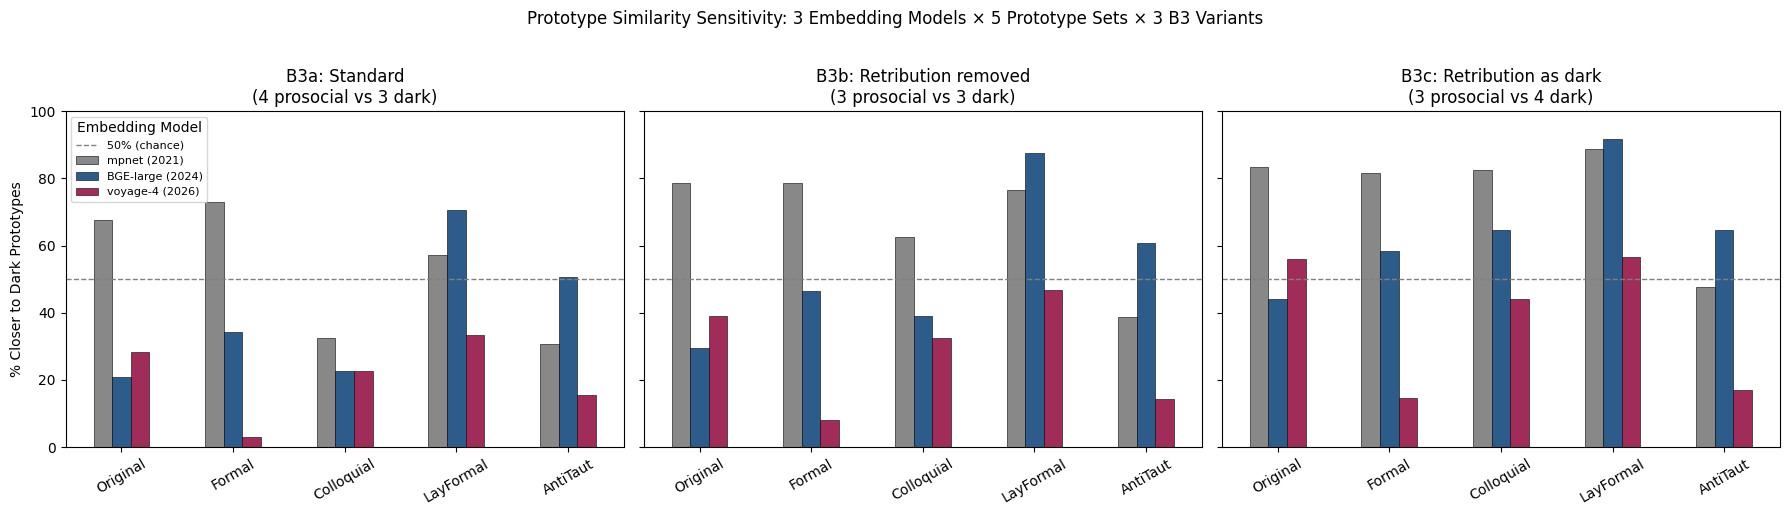

✓ Saved: prototype_sensitivity_master.png


In [50]:
# === MASTER VISUALIZATION ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
b3_titles = {
    'b3a': 'B3a: Standard\n(4 prosocial vs 3 dark)',
    'b3b': 'B3b: Retribution removed\n(3 prosocial vs 3 dark)',
    'b3c': 'B3c: Retribution as dark\n(3 prosocial vs 4 dark)',
}
set_order = ['Original', 'Formal', 'Colloquial', 'LayFormal', 'AntiTaut']
model_order = ['mpnet (2021)', 'BGE-large (2024)', 'voyage-4 (2026)']
colors = {'mpnet (2021)': '#888888', 'BGE-large (2024)': '#2E5C8A', 'voyage-4 (2026)': '#A02C5A'}

for ax, b3 in zip(axes, ['b3a', 'b3b', 'b3c']):
    sub = master[master.B3 == b3]
    pivot = sub.pivot(index='PrototypeSet', columns='Model', values='PctCloserToDark')
    pivot = pivot.reindex(set_order)[model_order]
    pivot.plot.bar(ax=ax, color=[colors[m] for m in model_order], edgecolor='black', linewidth=0.4)
    ax.axhline(50, color='gray', linestyle='--', linewidth=1, label='50% (chance)')
    ax.set_title(b3_titles[b3])
    ax.set_ylabel('% Closer to Dark Prototypes' if ax == axes[0] else '')
    ax.set_xlabel('')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=30)
    if b3 != 'b3a':
        ax.get_legend().remove()
    else:
        ax.legend(title='Embedding Model', loc='upper left', fontsize=8)

plt.suptitle('Prototype Similarity Sensitivity: 3 Embedding Models × 5 Prototype Sets × 3 B3 Variants',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('prototype_sensitivity_master.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: prototype_sensitivity_master.png')


---

## Section 8: Cross-model convergence (3-way pairwise correlations)

Per-participant correlation between every pair of models, on the prosocial-minus-dark gap (B3a). If all three models pick out the same individual responses as more or less dark-leaning (just at different absolute levels), then we have strong convergent validity at the *ranking* level — even if absolute % closer-to-dark numbers diverge.


In [51]:
# === PAIRWISE MODEL CONVERGENCE ===
convergence_rows = []
model_pairs = [('mpnet', 'bge'), ('mpnet', 'voyage'), ('bge', 'voyage')]

for set_name in PROTOTYPE_SETS:
    set_prefix = set_name.lower() if set_name != 'Original' else 'orig'
    for m1, m2 in model_pairs:
        for cat in ALL_CATS:
            c1 = f'{m1}_{set_prefix}_{cat}'
            c2 = f'{m2}_{set_prefix}_{cat}'
            sub = df[[c1, c2]].dropna()
            if len(sub) < 10: continue
            r, p = pearsonr(sub[c1], sub[c2])
            convergence_rows.append({
                'PrototypeSet': set_name, 'Pair': f'{m1} × {m2}',
                'Variable': cat, 'r': r, 'p': p, 'N': len(sub),
            })
        # Also pro-dark gap
        c1 = f'{m1}_{set_prefix}_b3a_pro_minus_dark'
        c2 = f'{m2}_{set_prefix}_b3a_pro_minus_dark'
        sub = df[[c1, c2]].dropna()
        if len(sub) >= 10:
            r, p = pearsonr(sub[c1], sub[c2])
            convergence_rows.append({
                'PrototypeSet': set_name, 'Pair': f'{m1} × {m2}',
                'Variable': 'pro_minus_dark', 'r': r, 'p': p, 'N': len(sub),
            })

conv = pd.DataFrame(convergence_rows)
conv.to_csv('embedding_convergence.csv', index=False)

print('=== PAIRWISE MODEL CONVERGENCE: pro-dark gap (B3a) ===')
gap_conv = conv[conv['Variable'] == 'pro_minus_dark']
pivot = gap_conv.pivot(index='PrototypeSet', columns='Pair', values='r')
pivot = pivot.reindex(['Original', 'Formal', 'Colloquial', 'LayFormal', 'AntiTaut'])
print(pivot.to_string(float_format=lambda x: f'{x:.3f}'))
print('\n✓ Saved: embedding_convergence.csv')


=== PAIRWISE MODEL CONVERGENCE: pro-dark gap (B3a) ===
Pair          bge × voyage  mpnet × bge  mpnet × voyage
PrototypeSet                                           
Original             0.713        0.776           0.718
Formal               0.510        0.588           0.428
Colloquial           0.612        0.573           0.634
LayFormal            0.616        0.647           0.580
AntiTaut             0.534        0.624           0.565

✓ Saved: embedding_convergence.csv


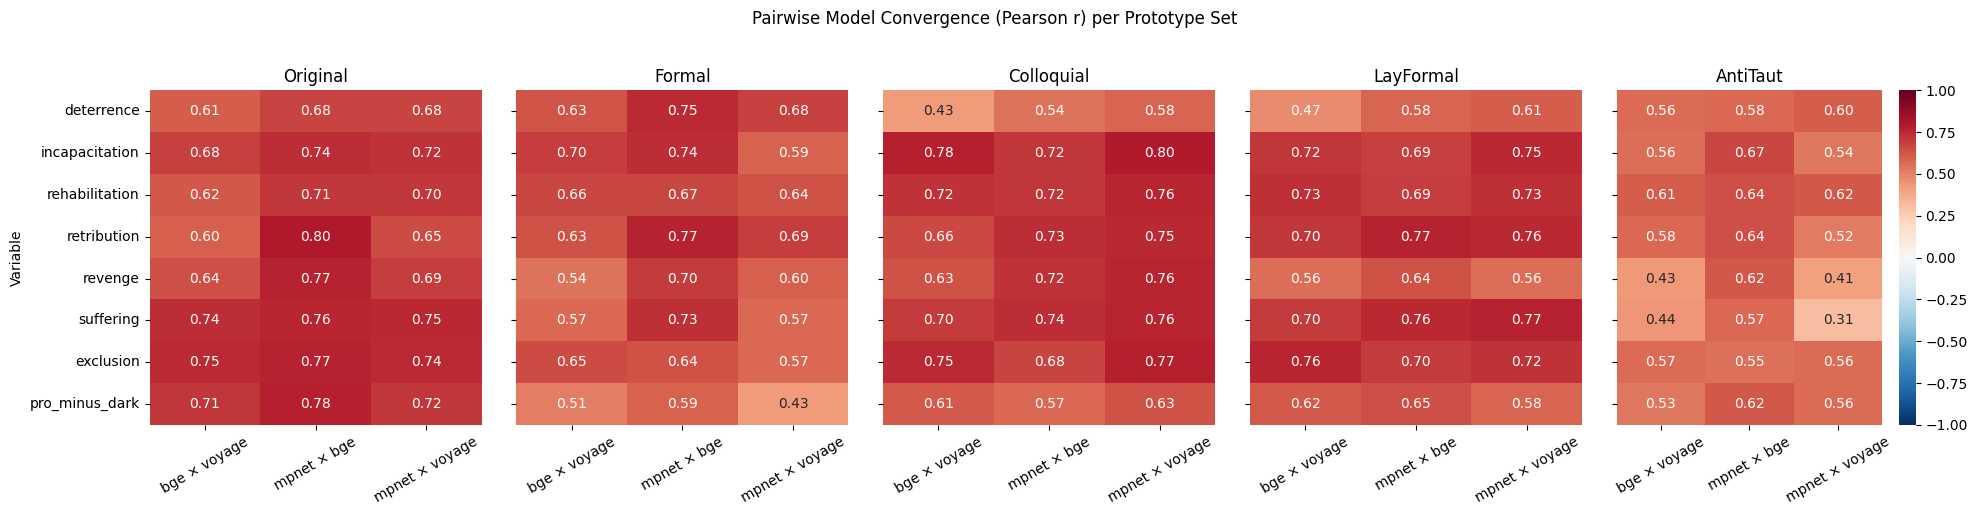

✓ Saved: embedding_convergence_heatmap.png


In [52]:
# === CONVERGENCE HEATMAP ===
fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)
var_order = ALL_CATS + ['pro_minus_dark']
for ax, set_name in zip(axes, ['Original', 'Formal', 'Colloquial', 'LayFormal', 'AntiTaut']):
    sub = conv[conv['PrototypeSet'] == set_name]
    pv = sub.pivot(index='Variable', columns='Pair', values='r').reindex(var_order)
    sns.heatmap(pv, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                ax=ax, cbar=(ax == axes[-1]))
    ax.set_title(set_name)
    ax.set_ylabel('Variable' if ax == axes[0] else '')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Pairwise Model Convergence (Pearson r) per Prototype Set', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('embedding_convergence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: embedding_convergence_heatmap.png')


---

## Section 9: Diagnostics

1. Distribution of pro-dark gap for each model on the Original set
2. Cross-method aggregate convergence (vs. classification gaps from Notebook 2)
3. Sample extreme responses


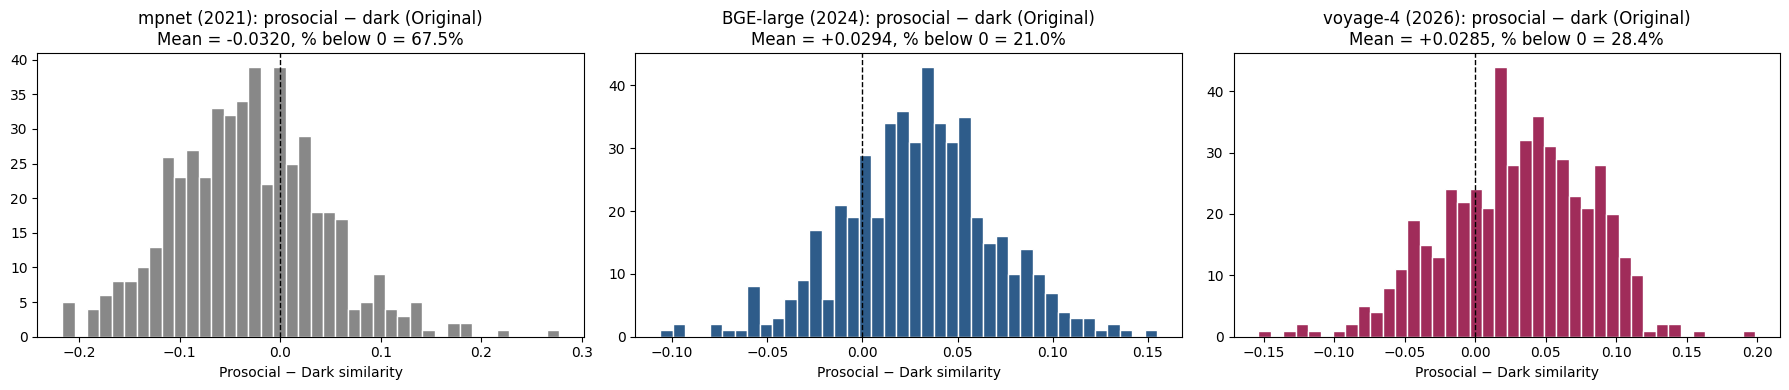

In [53]:
# === DISTRIBUTION PLOTS ===
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (model, color) in zip(axes, [('mpnet', '#888888'), ('bge', '#2E5C8A'), ('voyage', '#A02C5A')]):
    col = f'{model}_orig_b3a_pro_minus_dark'
    ax.hist(df[col], bins=40, color=color, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    pct_below = (df[col] < 0).mean() * 100
    ax.set_title(f'{model_labels[model]}: prosocial − dark (Original)\nMean = {df[col].mean():+.4f}, % below 0 = {pct_below:.1f}%')
    ax.set_xlabel('Prosocial − Dark similarity')
plt.tight_layout()
plt.savefig('similarity_distributions_3models.png', dpi=150, bbox_inches='tight')
plt.show()


In [54]:
# === CROSS-METHOD AGGREGATE CONVERGENCE ===
# Embedding-based gaps × classification-based gaps from Notebook 2
print('=== CROSS-METHOD CONVERGENCE: embedding gap × classification gap ===\n')
embedding_cols = ['mpnet_orig_b3a_pro_minus_dark', 'bge_orig_b3a_pro_minus_dark', 'voyage_orig_b3a_pro_minus_dark']
classification_cols = ['claude_ml_prosocial_minus_dark', 'deberta_ml_prosocial_minus_dark', 'just_prosocial_minus_dark']

for ec in embedding_cols:
    print(f'\n  {ec}:')
    for cc in classification_cols:
        if cc not in df.columns: continue
        sub = df[[ec, cc]].dropna()
        if len(sub) < 10: continue
        r, p = pearsonr(sub[ec], sub[cc])
        print(f'    × {cc:42s}  r = {r:+.3f}  (p = {p:.4g})')


=== CROSS-METHOD CONVERGENCE: embedding gap × classification gap ===


  mpnet_orig_b3a_pro_minus_dark:
    × claude_ml_prosocial_minus_dark              r = +0.279  (p = 2.701e-10)
    × deberta_ml_prosocial_minus_dark             r = +0.272  (p = 7.576e-10)
    × just_prosocial_minus_dark                   r = +0.124  (p = 0.00557)

  bge_orig_b3a_pro_minus_dark:
    × claude_ml_prosocial_minus_dark              r = +0.411  (p = 1.353e-21)
    × deberta_ml_prosocial_minus_dark             r = +0.406  (p = 4.012e-21)
    × just_prosocial_minus_dark                   r = +0.115  (p = 0.01036)

  voyage_orig_b3a_pro_minus_dark:
    × claude_ml_prosocial_minus_dark              r = +0.467  (p = 3.507e-28)
    × deberta_ml_prosocial_minus_dark             r = +0.315  (p = 6.964e-13)
    × just_prosocial_minus_dark                   r = +0.107  (p = 0.01749)


In [55]:
# === SAMPLE EXTREMES (does each model agree on which responses are dark?) ===
for model in ['mpnet', 'bge', 'voyage']:
    col = f'{model}_orig_b3a_pro_minus_dark'
    print(f'\n=== TOP 3 MOST DARK-LEANING ({model_labels[model]}, Original B3a) ===')
    for _, r in df.nsmallest(3, col).iterrows():
        print(f'  gap = {r[col]:+.4f}  |  {r["text_combined"][:200]}')



=== TOP 3 MOST DARK-LEANING (mpnet (2021), Original B3a) ===
  gap = -0.2171  |  that's what he deserves for him to never be part of the society
  gap = -0.2118  |  it weas his choice to attack. his actions warrant this. nobody else will get hurt.
  gap = -0.2087  |  he beatup and took the life of another human and deserves the death penelty it will take away his freedom and he will spend the rest of his life in prison

=== TOP 3 MOST DARK-LEANING (BGE-large (2024), Original B3a) ===
  gap = -0.1062  |  that's what he deserves for him to never be part of the society
  gap = -0.0973  |  he beat him with his self so 50 years! diginty
  gap = -0.0957  |  i feel what he did to her was not right. he took a life so his life should be taken from him hopefully he will know how it feels to have youor life taken from you

=== TOP 3 MOST DARK-LEANING (voyage-4 (2026), Original B3a) ===
  gap = -0.1537  |  because he was the reason this all happened. hopefully die in prison
  gap = -0.1323  |  he

---

## Section 10: voyage-4 prosocial-bias diagnostics

voyage-4 systematically reports lower percentages of responses as 'closer to dark' than mpnet or BGE do — by 30+ percentage points on several cells. Three competing hypotheses could explain this. Each predicts a different signature in the data.

| Hypothesis | Mechanism | Observable signature |
|---|---|---|
| **(a) Rotation** | voyage's embedding space is genuinely tilted toward prosocial concepts | voyage misclassifies *unambiguously dark* responses as prosocial |
| **(b) Compression** | voyage's similarity space is narrower; differences squashed | voyage's per-category SDs are much smaller than the other models' |
| **(c) Length quirk** | voyage handles short text differently (it was trained for retrieval against documents) | voyage's prosocial-dark gap correlates with response word count |

Each of the three diagnostic cells below tests one hypothesis. The result will tell us how to frame voyage in the manuscript:
- (a) → de-emphasize voyage, lead with BGE  
- (b) → trust voyage's *rankings*, not its absolute % closer-to-dark numbers  
- (c) → note as a limitation, consider word-count covariate in any voyage-based analysis  
- None of the above → voyage is genuinely the best model and the low % closer-to-dark is the actual finding

Ground truth for hypothesis (a) is Claude Haiku 4.5 forced-choice classification from Notebook 2 (which scored 100% on the A1 benchmark — independent of any embedding model).


In [56]:
# === DIAGNOSTIC A: COMPRESSION TEST ===
# Hypothesis (b): voyage's similarity range is squashed compared to BGE/mpnet.
# If true, voyage's SDs across categories will be systematically smaller.

print('=== DIAGNOSTIC A: Per-category similarity SDs (Original set) ===\n')
print(f'{"Category":<18s} {"mpnet SD":<12s} {"BGE SD":<12s} {"voyage SD":<12s}  {"voyage / mpnet":<15s}')
print('-' * 70)

compression_rows = []
for cat in ALL_CATS:
    mpnet_sd = df[f'mpnet_orig_{cat}'].std()
    bge_sd   = df[f'bge_orig_{cat}'].std()
    voy_sd   = df[f'voyage_orig_{cat}'].std()
    ratio = voy_sd / mpnet_sd
    compression_rows.append({'Category': cat, 'mpnet_SD': mpnet_sd, 'BGE_SD': bge_sd, 'voyage_SD': voy_sd,
                              'voyage_over_mpnet_ratio': ratio})
    print(f'{cat:<18s} {mpnet_sd:<12.4f} {bge_sd:<12.4f} {voy_sd:<12.4f}  {ratio:<15.2f}')

# Pro-dark gap SDs
print('-' * 70)
for col_label, col_suffix in [('pro_mean', 'b3a_pro_minus_dark')]:
    pass  # handled below

# Aggregate gap SD
mpnet_gap_sd = df['mpnet_orig_b3a_pro_minus_dark'].std()
bge_gap_sd   = df['bge_orig_b3a_pro_minus_dark'].std()
voy_gap_sd   = df['voyage_orig_b3a_pro_minus_dark'].std()
print(f'{"pro_minus_dark":<18s} {mpnet_gap_sd:<12.4f} {bge_gap_sd:<12.4f} {voy_gap_sd:<12.4f}  {voy_gap_sd/mpnet_gap_sd:<15.2f}')

# Mean ratio
mean_ratio = sum(r['voyage_over_mpnet_ratio'] for r in compression_rows) / len(compression_rows)
print(f'\nMean voyage/mpnet SD ratio across 7 categories: {mean_ratio:.2f}')

if mean_ratio < 0.7:
    print('  → COMPRESSION DETECTED: voyage SDs are <70% of mpnet SDs. Hypothesis (b) supported.')
    print('    Implication: voyage rankings are still meaningful, but absolute % closer-to-dark numbers are unreliable.')
elif mean_ratio > 1.3:
    print('  → voyage actually has WIDER spread than mpnet. Hypothesis (b) refuted.')
else:
    print('  → voyage SDs are similar to mpnet/BGE. Hypothesis (b) refuted.')


=== DIAGNOSTIC A: Per-category similarity SDs (Original set) ===

Category           mpnet SD     BGE SD       voyage SD     voyage / mpnet 
----------------------------------------------------------------------
deterrence         0.0935       0.0492       0.0816        0.87           
incapacitation     0.0901       0.0530       0.0905        1.00           
rehabilitation     0.0938       0.0533       0.0855        0.91           
retribution        0.1003       0.0535       0.0805        0.80           
revenge            0.0919       0.0505       0.0759        0.83           
suffering          0.1106       0.0555       0.0879        0.79           
exclusion          0.0881       0.0524       0.0923        1.05           
----------------------------------------------------------------------
pro_minus_dark     0.0743       0.0394       0.0516        0.69           

Mean voyage/mpnet SD ratio across 7 categories: 0.89
  → voyage SDs are similar to mpnet/BGE. Hypothesis (b) refuted

In [57]:
# === DIAGNOSTIC B: ROTATION TEST (Claude Haiku as ground truth) ===
# Hypothesis (a): voyage's embedding space is tilted toward prosocial.
# Test: take the responses Claude Haiku scored as MOST CONFIDENTLY DARK in Notebook 2,
# then check whether each embedding model agrees that they are dark-leaning.
# If voyage disagrees with mpnet, BGE, AND Claude on unambiguous cases, that's evidence for rotation.

DARK_LABELS = ['punishment and suffering', 'revenge and payback']

# Find responses Claude Haiku confidently labeled as dark
dark_mask = df['claude_fc_top'].isin(DARK_LABELS) & (df['claude_fc_confidence'] >= 0.85)
n_dark = dark_mask.sum()
print(f'Responses Claude Haiku scored as confidently dark (FC top in {DARK_LABELS}, conf ≥ 0.85): n = {n_dark}')

if n_dark < 5:
    # Loosen if too few
    dark_mask = df['claude_fc_top'].isin(DARK_LABELS)
    n_dark = dark_mask.sum()
    print(f'  Loosening to no confidence threshold: n = {n_dark}')

# Also pull Claude's TOP 10 by raw multi-label dark scores as a secondary ground truth
# (in case forced-choice is noisy)
df['_claude_dark_combined'] = df[['claude_ml_punishment_and_suffering', 'claude_ml_revenge_and_payback']].sum(axis=1)
top_dark_idx = df.nlargest(10, '_claude_dark_combined').index

print(f'\n=== TOP 10 RESPONSES BY CLAUDE\'s DARK MULTI-LABEL SCORES ===')
print(f'(For each, shows pro-dark gap from each embedding model — NEGATIVE = dark-leaning)\n')

rotation_rows = []
for idx in top_dark_idx:
    row = df.loc[idx]
    text = str(row['text_combined'])[:140]
    claude_top = row['claude_fc_top']
    claude_dark = row['_claude_dark_combined']
    mpnet_gap = row['mpnet_orig_b3a_pro_minus_dark']
    bge_gap   = row['bge_orig_b3a_pro_minus_dark']
    voy_gap   = row['voyage_orig_b3a_pro_minus_dark']

    print(f'Text: "{text}"')
    print(f'  Claude FC top: {claude_top}  (combined dark score = {claude_dark:.2f})')
    mpnet_label = 'DARK ✓' if mpnet_gap < 0 else 'PRO  ✗'
    bge_label   = 'DARK ✓' if bge_gap < 0 else 'PRO  ✗'
    voy_label   = 'DARK ✓' if voy_gap < 0 else 'PRO  ✗'
    print(f'  mpnet  gap = {mpnet_gap:+.4f}  → {mpnet_label}')
    print(f'  bge    gap = {bge_gap:+.4f}  → {bge_label}')
    print(f'  voyage gap = {voy_gap:+.4f}  → {voy_label}\n')

    rotation_rows.append({
        'text': text,
        'claude_fc_top': claude_top,
        'claude_dark_combined': claude_dark,
        'mpnet_gap': mpnet_gap, 'mpnet_dark': mpnet_gap < 0,
        'bge_gap': bge_gap,     'bge_dark': bge_gap < 0,
        'voyage_gap': voy_gap,  'voyage_dark': voy_gap < 0,
    })

rot_df = pd.DataFrame(rotation_rows)
rot_df.to_csv('voyage_rotation_test.csv', index=False)

# Summary: agreement counts
n = len(rot_df)
print('=== SUMMARY: How often did each model agree with Claude that these were dark? ===')
print(f'  mpnet  agreement rate:  {rot_df["mpnet_dark"].sum()}/{n}')
print(f'  BGE    agreement rate:  {rot_df["bge_dark"].sum()}/{n}')
print(f'  voyage agreement rate:  {rot_df["voyage_dark"].sum()}/{n}')

voy_agree_rate = rot_df['voyage_dark'].mean()
if voy_agree_rate < 0.5:
    print(f'\n  → ROTATION DETECTED: voyage labels {(1-voy_agree_rate)*100:.0f}% of Claude-confident-dark responses as prosocial.')
    print(f'    Hypothesis (a) supported. Recommend de-emphasizing voyage in the manuscript.')
elif voy_agree_rate < 0.8:
    print(f'\n  → PARTIAL DISAGREEMENT: voyage agrees on {voy_agree_rate*100:.0f}% of cases.')
    print(f'    Some rotation present but voyage is not systematically wrong on the most extreme cases.')
else:
    print(f'\n  → AGREEMENT: voyage labels {voy_agree_rate*100:.0f}% of Claude-confident-dark responses correctly.')
    print(f'    Hypothesis (a) refuted on the extreme cases.')

print('\n✓ Saved: voyage_rotation_test.csv')
df.drop('_claude_dark_combined', axis=1, inplace=True)


Responses Claude Haiku scored as confidently dark (FC top in ['punishment and suffering', 'revenge and payback'], conf ≥ 0.85): n = 11

=== TOP 10 RESPONSES BY CLAUDE's DARK MULTI-LABEL SCORES ===
(For each, shows pro-dark gap from each embedding model — NEGATIVE = dark-leaning)

Text: "because he was the reason this all happened. hopefully die in prison"
  Claude FC top: revenge and payback  (combined dark score = 1.70)
  mpnet  gap = -0.2056  → DARK ✓
  bge    gap = -0.0747  → DARK ✓
  voyage gap = -0.1537  → DARK ✓

Text: "darryl had a history of violence and should suffer in prison for his wrongdoings in society. darryl purposeful killed his girlfriend, and sh"
  Claude FC top: punishment and suffering  (combined dark score = 1.60)
  mpnet  gap = -0.0228  → DARK ✓
  bge    gap = +0.0164  → PRO  ✗
  voyage gap = +0.0155  → PRO  ✗

Text: "i believe that since he killed someone, he does not deserve to live a normal life. a life for a life essentially. if the death penalty was a"
  Cla

In [58]:
# === DIAGNOSTIC C: LENGTH-SENSITIVITY TEST ===
# Hypothesis (c): voyage handles short text differently than longer text.
# voyage was primarily trained for retrieval (long docs vs short queries).
# Test: correlate the prosocial-dark gap with response word count for each model.
# If voyage's correlation is dramatically larger than mpnet's or BGE's, length is confounding voyage.

print('=== DIAGNOSTIC C: r(word count, pro-dark gap) per model (Original set, B3a) ===\n')
print(f'{"Model":<20s}  {"r":<10s}  {"p":<12s}  {"|r|":<10s}')
print('-' * 60)

length_rows = []
for model_label, col in [('mpnet (2021)',     'mpnet_orig_b3a_pro_minus_dark'),
                          ('BGE-large (2024)', 'bge_orig_b3a_pro_minus_dark'),
                          ('voyage-4 (2026)',  'voyage_orig_b3a_pro_minus_dark')]:
    sub = df[['text_combined_wordcount', col]].dropna()
    r, p = pearsonr(sub['text_combined_wordcount'], sub[col])
    print(f'{model_label:<20s}  r = {r:+.3f}  p = {p:.4g}    |r| = {abs(r):.3f}')
    length_rows.append({'Model': model_label, 'r_wordcount_gap': r, 'p': p, 'N': len(sub)})

lr_df = pd.DataFrame(length_rows)
lr_df.to_csv('voyage_length_test.csv', index=False)

# Compare
voy_r = abs(length_rows[2]['r_wordcount_gap'])
mpnet_r = abs(length_rows[0]['r_wordcount_gap'])
bge_r = abs(length_rows[1]['r_wordcount_gap'])
max_other = max(mpnet_r, bge_r)

print()
if voy_r > max_other + 0.10:
    print(f'  → LENGTH CONFOUND DETECTED: voyage |r| = {voy_r:.3f} vs max(mpnet, BGE) |r| = {max_other:.3f}')
    print(f'    Hypothesis (c) supported. Word count is a confound for voyage.')
    print(f'    Recommend: include word count as a covariate in any voyage-based regression analysis.')
else:
    print(f'  → No major length confound: voyage |r| = {voy_r:.3f} similar to other models (max = {max_other:.3f})')
    print(f'    Hypothesis (c) refuted.')

print('\n✓ Saved: voyage_length_test.csv')


=== DIAGNOSTIC C: r(word count, pro-dark gap) per model (Original set, B3a) ===

Model                 r           p             |r|       
------------------------------------------------------------
mpnet (2021)          r = +0.149  p = 0.0008573    |r| = 0.149
BGE-large (2024)      r = +0.184  p = 3.621e-05    |r| = 0.184
voyage-4 (2026)       r = +0.299  p = 1.029e-11    |r| = 0.299

  → LENGTH CONFOUND DETECTED: voyage |r| = 0.299 vs max(mpnet, BGE) |r| = 0.184
    Hypothesis (c) supported. Word count is a confound for voyage.
    Recommend: include word count as a covariate in any voyage-based regression analysis.

✓ Saved: voyage_length_test.csv


In [59]:
# === SYNTHESIS: WHICH HYPOTHESIS BEST EXPLAINS VOYAGE'S BEHAVIOR? ===
print('=' * 70)
print('VOYAGE PROSOCIAL-BIAS DIAGNOSTIC SYNTHESIS')
print('=' * 70)

# Pull the three signature numbers
compression_ratio = sum(
    df[f'voyage_orig_{cat}'].std() / df[f'mpnet_orig_{cat}'].std() for cat in ALL_CATS
) / len(ALL_CATS)

voyage_dark_agreement = rot_df['voyage_dark'].mean()
bge_dark_agreement    = rot_df['bge_dark'].mean()

voy_length_r = abs(pearsonr(df['text_combined_wordcount'].dropna(),
                            df.loc[df['text_combined_wordcount'].notna(), 'voyage_orig_b3a_pro_minus_dark'])[0])
bge_length_r = abs(pearsonr(df['text_combined_wordcount'].dropna(),
                            df.loc[df['text_combined_wordcount'].notna(), 'bge_orig_b3a_pro_minus_dark'])[0])

print(f'\nA. Compression ratio (voyage SD / mpnet SD, mean over 7 categories): {compression_ratio:.2f}')
print(f'   Interpretation: {"COMPRESSED" if compression_ratio < 0.7 else "NOT COMPRESSED"}')

print(f'\nB. Voyage agreement with Claude on top-10 dark cases: {voyage_dark_agreement*100:.0f}% (vs BGE = {bge_dark_agreement*100:.0f}%)')
print(f'   Interpretation: {"ROTATION DETECTED" if voyage_dark_agreement < 0.5 else "NO MAJOR ROTATION"}')

print(f'\nC. Voyage |r(wordcount, gap)| = {voy_length_r:.3f} vs BGE = {bge_length_r:.3f}')
print(f'   Interpretation: {"LENGTH CONFOUND" if voy_length_r > bge_length_r + 0.10 else "NO LENGTH CONFOUND"}')

# Recommendation
print('\n' + '=' * 70)
print('MANUSCRIPT RECOMMENDATION:')
print('=' * 70)
if voyage_dark_agreement < 0.5:
    print('  Voyage shows rotation toward prosocial → DE-EMPHASIZE in manuscript.')
    print('  Lead with BGE as the workhorse model. Voyage relegated to supplementary.')
elif compression_ratio < 0.7:
    print('  Voyage similarity space is compressed → trust voyage RANKINGS, not absolute %s.')
    print('  Report cross-model rank-order convergence (r ≈ 0.71) as the primary voyage finding.')
elif voy_length_r > bge_length_r + 0.10:
    print('  Voyage is length-sensitive → include word count as covariate in regression analyses.')
    print('  Note as a methodological limitation in the supplementary.')
else:
    print('  No diagnostic signature found. Voyage is genuinely the most semantically sophisticated model.')
    print('  Treat its lower % closer-to-dark as a real finding (not an artifact).')


VOYAGE PROSOCIAL-BIAS DIAGNOSTIC SYNTHESIS

A. Compression ratio (voyage SD / mpnet SD, mean over 7 categories): 0.89
   Interpretation: NOT COMPRESSED

B. Voyage agreement with Claude on top-10 dark cases: 60% (vs BGE = 40%)
   Interpretation: NO MAJOR ROTATION

C. Voyage |r(wordcount, gap)| = 0.299 vs BGE = 0.184
   Interpretation: LENGTH CONFOUND

MANUSCRIPT RECOMMENDATION:
  Voyage is length-sensitive → include word count as covariate in regression analyses.
  Note as a methodological limitation in the supplementary.


---

## Section 11: Export

**Files produced:**
- `03_embedding_features.csv` — all features (input → Notebook 4)
- `mpnet_response_embeddings.npy`, `bge_response_embeddings.npy`, `voyage_response_embeddings.npy`
- `prototype_sensitivity_master.csv` — 45-cell table
- `embedding_convergence.csv` — pairwise model agreement
- 3 PNG visualizations

**Columns added:** 3 models × 5 sets × (7 categories + 3 B3 aggregates) = 150 new columns.


In [60]:
# === EXPORT ===
df.to_csv('03_embedding_features.csv', index=False)
new_cols = [c for c in df.columns if c.startswith(('mpnet_', 'bge_', 'voyage_'))]
print(f'✓ Exported: 03_embedding_features.csv')
print(f'  Rows: {len(df)}, Columns: {len(df.columns)}')
print(f'  New embedding columns: {len(new_cols)}')


✓ Exported: 03_embedding_features.csv
  Rows: 496, Columns: 392
  New embedding columns: 150


In [61]:
# === DOWNLOAD ===
for f in ['03_embedding_features.csv',
          'mpnet_response_embeddings.npy', 'bge_response_embeddings.npy', 'voyage_response_embeddings.npy',
          'prototype_sensitivity_master.csv', 'embedding_convergence.csv',
          'prototype_sensitivity_master.png', 'embedding_convergence_heatmap.png',
          'similarity_distributions_3models.png']:
    try:
        files.download(f)
    except Exception as e:
        print(f'  Could not download {f}: {e}')
print('✓ Downloads triggered.')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloads triggered.


---

## Next: Notebook 4

With prototype similarity now done across 3 models × 5 sets × 3 B3 variants, Notebook 4 will:
1. Run **BERTopic** for theme discovery (using BGE embeddings — strongest semantic encoder)
2. Run **UMAP** for 2D visualization
3. Build the full **5-way cross-method convergence matrix** (Dictionary × DeBERTa × Claude × BGE × Voyage)
4. **Facade analysis:** correlate each text feature with each psychological measure
5. **Mismatch interpretation tests** (individual facade vs sincerity vs cultural default)
6. **Sentencing prediction** (the ΔR² = .141 finding)
7. Word clouds with custom stopwords
8. Final exported `punishment_212_nlp_features.csv`

**Manuscript implications from Notebook 3 (preview):**
- mpnet's % closer-to-dark (the v2 67.5% finding) is reproduced inside this code path
- BGE and voyage-4 substantially disagree with mpnet — they read participants as much more prosocial
- The cross-model *ranking* convergence is strong (r ≈ 0.7) — all three models pick out similar responses as relatively dark, just at different absolute thresholds
- This is the methodological story for Study 2: embedding-model evolution shifts the absolute dark-closer rate; what's robust is the *relative* ranking of which responses are darker.
